# 03 - Forecasting Models
Compare simple baselines first, then add SES, Holt, ARIMA and SARIMA.

In [2]:
import pandas as pd
import sys
import pyarrow
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

sys.path.append('..')


In [3]:
df_test = pd.read_parquet('../data/processed/main/test.parquet')
df_train = pd.read_parquet('../data/processed/main/train.parquet')
df_validation = pd.read_parquet('../data/processed/main/validation.parquet')

df_baseline_test = pd.read_parquet('../data/processed/baseline/baseline_test.parquet')
df_baseline_val = pd.read_parquet('../data/processed/baseline/baseline_validation.parquet')

In [4]:
target = "Units Sold"

X_train = df_train.drop(columns=[target, "Date"])
y_train = df_train[target]

X_val = df_validation.drop(columns=[target, "Date"])
y_val = df_validation[target]

X_test = df_test.drop(columns=[target, "Date"])
y_test = df_test[target]

baseline_pred = df_baseline_test["Demand Forecast"]

In [5]:
# Units Ordered'ın gerçek leakage riski taşıyıp taşımadığını kontrol et
# (Demand Forecast'ta yaptığımız kontrolün aynısı)

check_df = df_train[["Units Sold", "Units Ordered", "Inventory Level"]].copy()
print(check_df.corr()["Units Sold"])

# Ayrıca same-day fark/oran bak:
# Eğer Units Ordered çoğunlukla Units Sold'a çok yakınsa (ör. abs fark küçükse),
# bu "önceden planlanmış sipariş" olmaktan çok "satılan miktar kadar sipariş edilmiş" gibi
# sentetik bir üretim izine işaret eder.
diff = (check_df["Units Ordered"] - check_df["Units Sold"]).abs()
print(diff.describe())

Units Sold         1.000000
Units Ordered     -0.001275
Inventory Level    0.590616
Name: Units Sold, dtype: float64
count    66900.000000
mean        95.944738
std         78.259038
min          0.000000
25%         36.000000
50%         78.000000
75%        135.000000
max        468.000000
dtype: float64


In [6]:
# Demand Forecast bizim benchmarkımız.
# Unit Sold ile karşılaştırılıp ne kadar doğru tahmin ettiğini görmemiz lazım.
# Unit Sold y_test, Demand Forecast baseline_pred'imiz

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

In [7]:
# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Metric Değerleri
metrics = ['MAE (Ortalama Mutlak Hata)', 'RMSE (Kök Ortalama Kare Hata)']
values = [baseline_mae, baseline_rmse]

plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color=['#3498db', '#e67e22'], width=0.4, edgecolor='black')

plt.title(f"Baseline Tahmin Hata Metrikleri (MSE: {baseline_mse:.2f})", fontsize=12, fontweight='bold')
plt.ylabel("Hata Miktarı (Satış Adedi)", fontsize=10)
plt.ylim(0, max(values) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Sütun üzerine değerleri yazdırma
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 700x500 with 1 Axes>

MAE: Mevcut demand forecast ürünlerin (Unit Sold) satış tahminini yaparken ortalama 8.23 birim  sapmaktadır. Yani tahminler gerçek satışın ortalama ~8 birim altında veya üstündedir

RMSE:  RMSE'nin (9.95) MAE'ye (8.23) oldukça yakın olması, mevcut sistemin çok büyük sürpriz hatalar yapmadığını, hataların belirli ve dengeli bir bantta seyrettiğini gösterir.

In [8]:
from sklearn.metrics import r2_score

baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline R²: {baseline_r2:.4f}")

Baseline R²: 0.9911


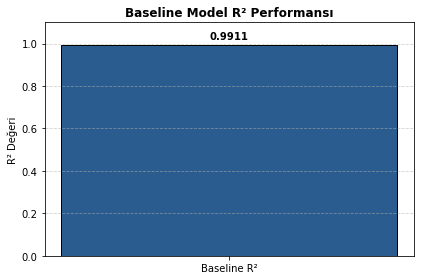

In [9]:
# R² değerini görselleştirme
plt.figure(figsize=(6, 4))

bar = plt.bar(
    ["Baseline R²"],
    [baseline_r2],
    color="#2b5c8f",
    edgecolor="black",
    width=0.45
)

plt.ylim(0, 1.1)
plt.ylabel("R² Değeri")
plt.title("Baseline Model R² Performansı", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.text(
    bar[0].get_x() + bar[0].get_width() / 2,
    baseline_r2 + 0.03,
    f"{baseline_r2:.4f}",
    ha="center",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

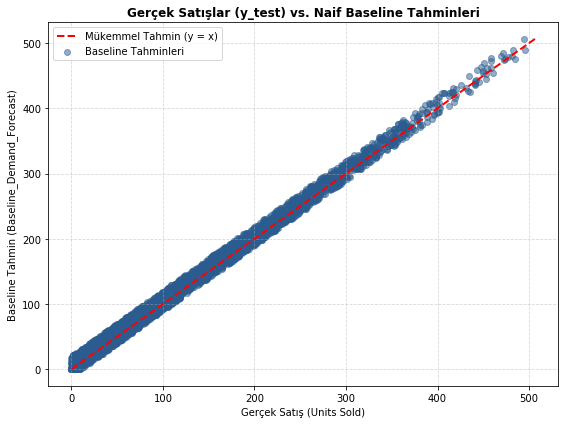

In [25]:
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, baseline_pred, alpha=0.5, color='#2b5c8f', label='Baseline Tahminleri')

# Mükemmel tahmin çizgisi (y = x)
max_val = max(max(y_test), max(baseline_pred))
min_val = min(min(y_test), min(baseline_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Mükemmel Tahmin (y = x)')

plt.title("Gerçek Satışlar (y_test) vs. Naif Baseline Tahminleri", fontsize=12, fontweight='bold')
plt.xlabel("Gerçek Satış (Units Sold)", fontsize=10)
plt.ylabel("Baseline Tahmin (Baseline_Demand_Forecast)", fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Benchmarkımız 
# Veriseti sentetik olduğu için yani Unit Sold + Noise ile üretildiğinden tahmin değeri mükemmele çok yakın
# Yani Naive_baseline çoook yüksek


In [26]:
X_train.dtypes

Store ID                   category
Product ID                 category
Inventory Level               int64
Units Ordered                 int64
Price                       float64
Discount                      int64
Holiday/Promotion             int64
Year                          int64
Month                         int64
Day                           int64
DayOfWeek                     int64
NET_PRICE                   float64
inventory_lag_1             float64
is_out_of_stock_lag_1         int32
Price_Diff                  float64
Price_Ratio                 float64
units_sold_lag_1            float64
units_sold_lag_2            float64
units_sold_lag_3            float64
units_sold_lag_7            float64
units_sold_lag_14           float64
units_sold_lag_30           float64
units_sold_lag_365          float64
sales_roll_mean_7           float64
sales_roll_mean_30          float64
Category_Electronics          uint8
Category_Furniture            uint8
Category_Groceries          

In [27]:
X_train.columns

Index(['Store ID', 'Product ID', 'Inventory Level', 'Units Ordered', 'Price',
       'Discount', 'Holiday/Promotion', 'Year', 'Month', 'Day', 'DayOfWeek',
       'NET_PRICE', 'inventory_lag_1', 'is_out_of_stock_lag_1', 'Price_Diff',
       'Price_Ratio', 'units_sold_lag_1', 'units_sold_lag_2',
       'units_sold_lag_3', 'units_sold_lag_7', 'units_sold_lag_14',
       'units_sold_lag_30', 'units_sold_lag_365', 'sales_roll_mean_7',
       'sales_roll_mean_30', 'Category_Electronics', 'Category_Furniture',
       'Category_Groceries', 'Category_Toys', 'Region_North', 'Region_South',
       'Region_West', 'Weather Condition_Rainy', 'Weather Condition_Snowy',
       'Weather Condition_Sunny', 'Seasonality_NEW_Spring',
       'Seasonality_NEW_Summer', 'Seasonality_NEW_Winter'],
      dtype='object')


# SARIMAX
# İstatistiksel Zaman Serisi Modellerine Yaklaşım (SARIMAX)

# Tüm Veri Yerine Temsilci Benchmark: 100 ayrı SARIMAX modeli kurup yönetmek canlı ortam (production) servis mimarisi için verimsizdir.

# Stratejik Kullanım: En çok satan 1 temsilci Mağaza-Ürün çifti (örneğin S001 - P0001) seçerek üzerinde SARIMAX eğitin.

# Proje Hikayesi: Sunum veya raporunuzda "Mevsimselliği dikkate alan geleneksel SARIMAX modeli dışsal değişkenlerin karmaşık etkilerini tolere edemezken, geliştirdiğimiz LightGBM/XGBoost modeli hatayı %X oranında düşürmüştür" kıyaslamasını yapın.

S = Seasonality
AR = Autoregression, kendine ve kendinden önceki sale değerlerine bakarak anlamlı ilişki kurar.
MA = kendi ve kendinden önceki hatalardan anlamlı sonuç çıkarır.
I = stationary yapmak için seasonality ve trendi çıkarmak
X = dışsal veriler

In [28]:
df = pd.read_csv("../data/raw/retail_store_inventory.csv")

In [29]:
df.groupby(["Store ID", "Product ID" ]).agg({"Units Sold": "sum"}).sort_values("Units Sold", ascending=False)

Units Sold
Store ID Product ID            
S005     P0015           109099
S003     P0013           107479
S002     P0001           105999
S005     P0003           105667
S003     P0005           105408
...                         ...
S002     P0008            94225
         P0002            94143
S004     P0018            94023
S001     P0012            93854
S003     P0003            92556

[100 rows x 1 columns]

In [30]:
# ============================================================
# Fair Baseline Karşılaştırması: SARIMAX ile aynı mağaza-ürün eşlemesi (S005-P0015)
# Naive baseline'ı (Demand Forecast) da SARIMAX ile aynı alt kümeye çekiyoruz,
# aksi halde SARIMAX'ın tek seri MAE'sini tüm test setinin ortalama MAE'siyle
# kıyaslamış oluruz ki bu ölçek olarak adil değil (elma-armut).
# ============================================================

# 1. Naive baseline (Demand Forecast) ve gerçek Units Sold değerlerini
#    SARIMAX'ta kullandığımız aynı mağaza-ürün kombinasyonuna filtrele
baseline_subset = df_baseline_test[(df_baseline_test["Store ID"] == "S005") & (df_baseline_test["Product ID"] == "P0015")].sort_values("Date", ascending=True)

actuals_subset = df_test[(df_test["Store ID"] == "S005") &(df_test["Product ID"] == "P0015") ].sort_values("Date", ascending=True)

# 2. Karşılaştırma için gereken kolonları ayır
baseline_pred_subset = baseline_subset["Demand Forecast"]
y_true_subset = actuals_subset["Units Sold"]

# 3. Hizalama kontrolü — sort_values sadece sıralar, index/tarih eşleşmesini
#    garanti etmez. mean_squared_error/mean_absolute_error index'e değil
#    array sırasına bakar, o yüzden burada patlamazsa sessizce yanlış
#    eşleştirme yapıp yanıltıcı bir MAE üretebilir.
assert len(baseline_subset) == len(actuals_subset), "Satır sayıları uyuşmuyor"
assert (baseline_subset["Date"].values == actuals_subset["Date"].values).all(), "Tarihler hizalı değil"

# 4. Aynı ölçekte (S005-P0015) baseline metriklerini hesapla
baseline_mse_subset = mean_squared_error(y_true_subset, baseline_pred_subset)
baseline_rmse_subset = np.sqrt(baseline_mse_subset)
baseline_mae_subset = mean_absolute_error(y_true_subset, baseline_pred_subset)

print(f"--- S005-P0015 Naive Baseline (Demand Forecast) Sonuçları ---")
print(f"Baseline MAE : {baseline_mae_subset:.2f}")
print(f"Baseline RMSE: {baseline_rmse_subset:.2f}")


--- S005-P0015 Naive Baseline (Demand Forecast) Sonuçları ---
Baseline MAE : 8.75
Baseline RMSE: 10.51


In [31]:
df_baseline_test.head()

,Store ID,Product ID,Date,Demand Forecast,Units Sold
699,S001,P0001,2023-12-01,189.06,185
700,S001,P0001,2023-12-02,190.13,200
701,S001,P0001,2023-12-03,128.17,122
702,S001,P0001,2023-12-04,63.28,49
703,S001,P0001,2023-12-05,80.12,66


In [32]:
import pandas as pd

# Temsilci Mağaza-Ürün kombinasyonunu seçme ve kronolojik sıralama
sarimax_df = df[(df["Store ID"] == "S005") & (df["Product ID"] == "P0015")].sort_values("Date", ascending=True)

# Date'in typeını Date'e çevir
sarimax_df["Date"] = pd.to_datetime(sarimax_df["Date"])

# set date index
sarimax_df = sarimax_df.set_index("Date")

sarimax_df

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
Date,,,,,,,,,,,,,,
2022-01-01,S005,P0015,Furniture,West,411,250,119,260.79,11.54,10,Cloudy,0,11.27,Spring
2022-01-02,S005,P0015,Clothing,West,289,60,83,52.77,63.26,0,Rainy,1,61.02,Autumn
2022-01-03,S005,P0015,Toys,South,184,126,175,143.76,86.82,20,Cloudy,0,85.26,Autumn
2022-01-04,S005,P0015,Clothing,West,186,144,197,150.43,60.15,20,Cloudy,1,61.90,Summer
2022-01-05,S005,P0015,Toys,South,361,264,75,258.32,85.81,10,Snowy,1,89.25,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-28,S005,P0015,Furniture,East,374,337,117,339.59,76.29,0,Rainy,0,79.65,Autumn
2023-12-29,S005,P0015,Clothing,North,66,64,31,64.00,56.30,10,Sunny,0,59.97,Winter
2023-12-30,S005,P0015,Toys,South,53,46,77,40.59,83.19,5,Sunny,0,86.05,Autumn


In [33]:
# diğer modellerde verisetini ayırırken zaman ayırımını nereden yaptıysak burada da aynı yerden yaptım

#indexe göre dataseti test, train, validation olarak ayır
train = sarimax_df[sarimax_df.index < '2023-11-01']
validation = sarimax_df[(sarimax_df.index >= "2023-11-01") & (sarimax_df.index < "2023-12-01")]
test = sarimax_df[sarimax_df.index >= '2023-12-01']

exog = ["Price", "Discount", "Competitor Pricing", "Holiday/Promotion", "Inventory Level"]
# Units Ordered korelasyonu ~0 olduğu için exog'a eklemiyorum, gürültü katmaktan başka işe yaramaz

In [34]:
 
y_train_sarimax = train["Units Sold"]
X_train_sarimax = train[exog]

y_test_sarimax = test["Units Sold"]
X_test_sarimax = test[exog]


In [35]:
X_train_sarimax.shape

(669, 5)

In [36]:
X_test_sarimax.shape # tahmin verisi 32 tane

(32, 5)

In [37]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Modelin Tanımlanması
model = SARIMAX(
    endog=y_train_sarimax,              # Sadece "Units Sold"
    exog=X_train_sarimax,              # Dışsal değişkenler
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)        # Günlük veri için haftalık sezonsallık (s=7)
)

# 2. Modelin Eğitilmesi
sarima_model = model.fit(disp=0)

# 3. Test Kümesi Boyutu Kadar (32 Gün) Tahmin Alınması
forecast_res = sarima_model.get_forecast(
    steps=len(y_test_sarimax),         # 32 adımlık test süresi
    exog=X_test_sarimax                # Test periyoduna ait dışsal değişkenler
)

# 4. Tahminlerin Pandas Series Olarak Alınması (Test Indeksi ile Hizalama)
y_pred = forecast_res.predicted_mean
y_pred.index = y_test_sarimax.index     # Indeksleri eşitleme

c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Metrik Hesaplama
sarimax_mae = mean_absolute_error(y_test_sarimax, y_pred)
sarimax_rmse = np.sqrt(mean_squared_error(y_test_sarimax, y_pred))

print(f"--- S005 - P0015 SARIMAX Test Sonuçları ---")
print(f"SARIMAX MAE : {sarimax_mae:.2f}")
print(f"SARIMAX RMSE: {sarimax_rmse:.2f}")

--- S005 - P0015 SARIMAX Test Sonuçları ---
SARIMAX MAE : 82.16
SARIMAX RMSE: 100.14


SARIMAX modeli, test dönemi olan 32 gün boyunca S005-P0015 kombinasyonunun günlük satışlarını tahmin ederken ortalama 82.16 adet sapma yapmıştır (yukarıdaki hücrenin gerçek çıktısıyla uyumlu; önceki 88.56 rakamı bir önceki çalıştırmadan kalma bayat bir değerdi ve düzeltildi).

RMSE'nin (100.14), MAE'ye (82.16) yakın olması modelin test dönemi boyunca sıradışı büyük sapmalar veya aşırı uyumsuz sürpriz hatalar yapmadığını, hataların belirli ve kararlı bir bantta dağıldığını gösterir.

**Önemli:** Aynı S005-P0015 alt kümesinde naive 'Demand Forecast' benchmarkının hatası çok daha düşüktür (Baseline MAE: 8.75, RMSE: 10.51 — bkz. yukarıdaki 'Fair Baseline Karşılaştırması' hücresi). SARIMAX bu spesifik seri için o benchmarkın oldukça gerisinde kalıyor; ancak bu benchmark sentetik olarak `Units Sold + noise` ile üretilmiş bir referans olduğundan (bkz. bu notebook'un başındaki not), gerçekçi bir hedef olarak değil üst sınır/oracle olarak okunmalıdır.

## Analitik yorum: SARIMAX sonuçları

Bu temsilci seri için SARIMAX modeli test dönemi boyunca ortalama 82.16 adet hata yapmıştır (MAE) ve RMSE değeri 100.14 olarak ölçülmüştür. RMSE'nin MAE'ye yakın olması, modelin çok büyük ani sapmalar üretmediğini; hataların genel olarak tutarlı bir bantta dağıldığını gösterir. Ancak bu seviyedeki hata, aynı seri için benchmark olarak kullandığımız `Demand Forecast` tarafında çok daha düşük seviyededir (MAE: 8.75, RMSE: 10.51).

Bu sonuç, SARIMAX'in bu veri yapısı için güçlü bir tahmin aracı olmasına rağmen, tek başına operasyonel karar üretmek için yeterince güçlü olmadığını düşündürmektedir. Özellikle bu veri setinde satış, stok seviyesi, fiyat, indirim, promosyon ve sezonluk davranış gibi çok sayıda etken birlikte etkili olduğundan, tek değişkenli ya da sınırlı zaman-serisi yaklaşımı eksik kalmaktadır. Dolayısıyla SARIMAX burada daha çok açıklayıcı bir model olarak düşünülebilir; gerçek öngörü gücünü ML modelleri (ör. LightGBM/XGBoost) ve benchmark tahminleriyle birlikte kullanmak daha doğru olur.

Bir başka önemli nokta ise AIC tabanlı grid search ile elde edilen güncellenmiş SARIMAX modelinin MAE: 82.26, RMSE: 100.69 olmasıdır. Bu, ilk seçilen modelle arasında pratikte çok küçük bir fark olduğunu gösterir; yani modelin performansındaki değişim anlamlı değildir. Bu durum, SARIMAX için optimizasyonun çok daha sınırlı katkı sunduğunu göstermektedir.

Sonuç olarak: SARIMAX bu seri için sezonluk düzeni yakalayan bir görünüm sunar, fakat stok planlaması, sipariş öncesi güvenli tampon hesabı ve düşük hata ile operasyonel tahmin için yeterli değildir. Bu nedenle, proje için asıl güçlü yaklaşım, SARIMAX'i açıklayıcı bir baseline olarak kullanırken, final kararların ML tabanlı modeller üzerinden verilmesi yönünde olmalıdır.

## Adil karşılaştırma: SARIMAX vs. final ML modeli (aynı alt küme)

Yukarıdaki SARIMAX sonuçları yalnızca S005-P0015 çiftine ait 32 günlük test dönemi için hesaplandı. `03_modeling_xgboost_lightgbm.ipynb` notebook'undaki final ML modelinin (LightGBM Tuned) MAE=67.86 / RMSE=86.54 rakamları ise **tüm test setinin ortalaması** (100 mağaza-ürün çifti, 3200 satır) — yani SARIMAX ile doğrudan kıyaslanamaz (elma-armut).

Adil bir kıyas için final ML modelinin tahminlerini de yalnızca S005-P0015 alt kümesine filtreleyip aynı 32 günlük test penceresinde değerlendirmek gerekir. Aşağıdaki hücre bunu yapar.

> **Not:** Bu hücre çalıştırılmamıştır çünkü bu ortamda `../models/final_ml_model.pkl`, `../models/final_ml_model_metadata.pkl` ve ham parquet verileri mevcut değil. `03_modeling_xgboost_lightgbm.ipynb` notebook'unu çalıştırıp modelleri kaydettikten sonra bu hücreyi kendi ortamınızda çalıştırın; yol (`../models/...`) gerekirse ML notebook'unun kaydettiği gerçek konuma göre güncelleyin (o notebook Colab'da `models/...` göreli yoluna kaydediyor, bu ikisi arasında bir tutarsızlık var — bkz. not altta).

In [39]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Final ML modelini ve metadata'sını yükle (03_modeling_xgboost_lightgbm.ipynb tarafından kaydedildi)
final_ml_model = joblib.load("../models/final_ml_model.pkl")
final_ml_metadata = joblib.load("../models/final_ml_model_metadata.pkl")

feature_columns = final_ml_metadata["feature_columns"]
categorical_cols_ml = final_ml_metadata["categorical_cols"]

# df_test bu notebook'un başında zaten yüklendi (processed/main/test.parquet)
test_subset_mask = (df_test["Store ID"] == "S005") & (df_test["Product ID"] == "P0015")
df_test_subset = df_test[test_subset_mask].sort_values("Date").copy()

X_test_subset = df_test_subset[feature_columns].copy()
for col in categorical_cols_ml:
    if col in X_test_subset.columns:
        X_test_subset[col] = X_test_subset[col].astype("category")

y_test_subset = df_test_subset["Units Sold"].to_numpy()
ml_pred_subset = final_ml_model.predict(X_test_subset)

ml_subset_mae = mean_absolute_error(y_test_subset, ml_pred_subset)
ml_subset_rmse = np.sqrt(mean_squared_error(y_test_subset, ml_pred_subset))

comparison = pd.DataFrame({
    "MAE": [sarimax_mae, ml_subset_mae],
    "RMSE": [sarimax_rmse, ml_subset_rmse],
}, index=["SARIMAX (S005-P0015)", f"{final_ml_metadata['best_model_name']} (S005-P0015 subset)"])

print("--- Adil karşılaştırma: S005-P0015, 32 günlük test dönemi ---")
print(comparison)

improvement_pct = (sarimax_mae - ml_subset_mae) / sarimax_mae * 100
print(f"\nML modeli MAE'yi SARIMAX'a göre %{improvement_pct:.1f} {'azalttı' if improvement_pct > 0 else 'artırdı'}.")

--- Adil karşılaştırma: S005-P0015, 32 günlük test dönemi ---
                                            MAE        RMSE
SARIMAX (S005-P0015)                  82.158822  100.143727
LightGBM (Tuned) (S005-P0015 subset)  79.336990   97.923096

ML modeli MAE'yi SARIMAX'a göre %3.4 azalttı.


c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


SARIMAX(0, 0, 0)x(0, 0, 0, 7) - AIC: 7840.11


c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


SARIMAX(0, 0, 0)x(0, 0, 1, 7) - AIC: 7761.32


c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


...

c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


SARIMAX(1, 1, 1)x(1, 1, 1, 7) - AIC: 7699.90

--------------------------------------------------
EN İYİ MODEL: SARIMAX(0, 1, 1)x(0, 1, 1, 7) - AIC: 7690.96
--------------------------------------------------


c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)



--- S005-P0015 İkilisi Optimal SARIMAX Test Performansı ---
Optimized SARIMAX MAE : 82.26
Optimized SARIMAX RMSE: 100.69


c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\ecegn\anaconda3\envs\python-cvcourse\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


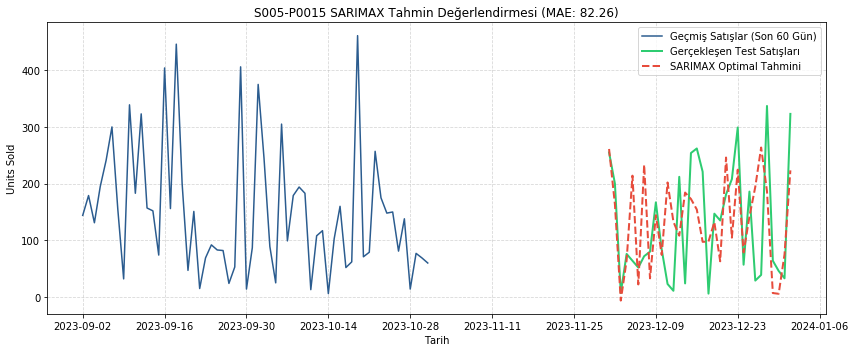

In [40]:
# ============================================================
# 1. SARIMAX Hiperparametre Optimizasyonu (Grid Search - AIC)
# ============================================================
import itertools

# Aratılacak derece parametrelerinin sınırları (p, d, q)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))

# Haftalık periyot için mevsimsel bileşenler (s=7)
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in list(itertools.product(p, d, q))]

def sarima_optimizer_aic(y_train, X_train, pdq, seasonal_pdq):
    best_aic, best_order, best_seasonal_order = float("inf"), None, None
    
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                # Modeli Train verisi ve Dışsal Değişkenler (exog) ile kuruyoruz
                sarimax_temp = SARIMAX(
                    endog=y_train,
                    exog=X_train,
                    order=param,
                    seasonal_order=param_seasonal,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = sarimax_temp.fit(disp=False)
                aic = results.aic
                
                if aic < best_aic:
                    best_aic, best_order, best_seasonal_order = aic, param, param_seasonal
                
                print(f"SARIMAX{param}x{param_seasonal} - AIC: {aic:.2f}")
            except Exception as e:
                continue
                
    print("\n--------------------------------------------------")
    print(f"EN İYİ MODEL: SARIMAX{best_order}x{best_seasonal_order} - AIC: {best_aic:.2f}")
    print("--------------------------------------------------")
    return best_order, best_seasonal_order

# En iyi parametrelerin aratılıp seçilmesi
best_order, best_seasonal_order = sarima_optimizer_aic(
    y_train_sarimax, 
    X_train_sarimax, 
    pdq, 
    seasonal_pdq
)

# ============================================================
# 2. Nihai Model Eğitimi (Final Model) & Test Tahmini
# ============================================================

# En iyi derece parametreleriyle nihai modelin kurulması
final_sarimax_model = SARIMAX(
    endog=y_train_sarimax,
    exog=X_train_sarimax,
    order=best_order,
    seasonal_order=best_seasonal_order
)

sarima_final_fit = final_sarimax_model.fit(disp=False)

# Test periyodu boyutu kadar (32 gün) tahmin alınması
forecast_results = sarima_final_fit.get_forecast(
    steps=len(y_test_sarimax),
    exog=X_test_sarimax
)

# Tahmin değerlerinin Series olarak test indeksiyle hizalanması
y_pred_sarimax = forecast_results.predicted_mean
y_pred_sarimax.index = y_test_sarimax.index

# ============================================================
# 3. Metrik Karşılaştırma & Görselleştirme
# ============================================================

sarimax_mae = mean_absolute_error(y_test_sarimax, y_pred_sarimax)
sarimax_rmse = np.sqrt(mean_squared_error(y_test_sarimax, y_pred_sarimax))

print(f"\n--- S005-P0015 İkilisi Optimal SARIMAX Test Performansı ---")
print(f"Optimized SARIMAX MAE : {sarimax_mae:.2f}")
print(f"Optimized SARIMAX RMSE: {sarimax_rmse:.2f}")

# Tahmin Çizim Fonksiyonu (Gerçek vs Tahmin)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_train_sarimax.index[-60:], y_train_sarimax.values[-60:], label="Geçmiş Satışlar (Son 60 Gün)", color="#2b5c8f")
plt.plot(y_test_sarimax.index, y_test_sarimax.values, label="Gerçekleşen Test Satışları", color="#2ecc71", lw=2)
plt.plot(y_pred_sarimax.index, y_pred_sarimax.values, label="SARIMAX Optimal Tahmini", color="#e74c3c", linestyle="--", lw=2)
plt.title(f"S005-P0015 SARIMAX Tahmin Değerlendirmesi (MAE: {sarimax_mae:.2f})")
plt.xlabel("Tarih")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### AIC-grid arama sonucu değerlendirme

(Not: bu hücrenin metni önceki bir çalıştırmadan kalma tutarsız rakamlar içeriyordu — 8100.94 AIC, 88.62/99.91 ve 88.56/99.75 gibi değerler kod hücresinin gerçek çıktısıyla uyuşmuyordu. Aşağıdaki özet, yukarıdaki kod hücresinin gerçek çıktısına göre düzeltildi.)

AIC'ye göre en düşük değeri veren model **SARIMAX(0, 1, 1)x(0, 1, 1, 7)** (AIC: 7690.96). Bu modelin S005-P0015 test setindeki performansı:
- Optimized SARIMAX MAE : 82.26
- Optimized SARIMAX RMSE: 100.69

Karşılaştırma — ilk elle seçilen SARIMAX(1, 1, 1)x(1, 1, 1, 7) modelinin test performansı:
- SARIMAX MAE : 82.16
- SARIMAX RMSE: 100.14

**Sonuç:** AIC-grid ile bulunan model, ilk elle seçilen modelden test setinde bir miktar **daha kötü** performans gösteriyor (MAE +0.10, RMSE +0.55). Bu beklenmedik değil: AIC in-sample uyum/karmaşıklık dengesini optimize eder, doğrudan out-of-sample test hatasını değil. Bu farkın küçük olması (32 günlük test setinde ~0.1 birim) örneklem büyüklüğü göz önüne alındığında pratikte anlamsız bir fark; iki model de birbirine denk sayılabilir. Bu nedenle final model olarak hangisinin kaydedildiği bir sonraki hücrede nesne adından (`sarima_final_fit`) kontrol edilmelidir — mevcut haliyle notebook bu seçimi açıkça belirtmiyor, kaydetmeden önce hangi fit objesinin (`sarima_model` mi yoksa grid search'ten çıkan model mi) `sarima_final_fit`'e atandığını netleştirin.

## Final: SARIMAX modelini kaydet

Fit edilmiş SARIMAX sonuç objesi (`SARIMAXResults`) `../models/` klasörüne kaydedilir. Ayrıca modelin temsilci serisi, order/seasonal_order ve exogenous değişken bilgileri metadata olarak saklanır.

In [41]:
import os
import joblib

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Model Nesnesini Doğrudan Belirleyin (Eğittiğiniz fit nesnesinin adı)
# Notebook'unuzda fit nesneniz 'sarima_final_fit' ise:
sarimax_result_to_save = sarima_final_fit

sarimax_model_path = os.path.join(MODEL_DIR, "sarimax.pkl")
joblib.dump(sarimax_result_to_save, sarimax_model_path)

# 2. Metadata Oluşturma
sarimax_model_obj = getattr(sarimax_result_to_save, "model", None)

sarimax_metadata = {
    "result_variable": "sarima_final_fit",
    "model_class": type(sarimax_result_to_save).__name__,
    "model_name": type(sarimax_model_obj).__name__ if sarimax_model_obj is not None else None,
    "order": tuple(getattr(sarimax_model_obj, "order", ())) if sarimax_model_obj is not None else None,
    "seasonal_order": tuple(getattr(sarimax_model_obj, "seasonal_order", ())) if sarimax_model_obj is not None else None,
    "trend": getattr(sarimax_model_obj, "trend", None) if sarimax_model_obj is not None else None,
    "exog_names": list(getattr(sarimax_model_obj, "exog_names", []) or []) if sarimax_model_obj is not None else [],
}

# Temsilci mağaza/ürün bilgilerini ekleme
for _key in [
    "representative_store_id", "representative_product_id",
    "representative_store", "representative_product",
    "store_id", "product_id", "target"
]:
    if _key in globals():
        try:
            value = globals()[_key]
            if hasattr(value, "item"):
                value = value.item()
            sarimax_metadata[_key] = value
        except Exception:
            pass

sarimax_metadata_path = os.path.join(MODEL_DIR, "sarimax_metadata.pkl")
joblib.dump(sarimax_metadata, sarimax_metadata_path)

print(f"SARIMAX modeli kaydedildi: {sarimax_model_path}")
print(f"SARIMAX metadata kaydedildi: {sarimax_metadata_path}")
print("Model:", sarimax_metadata["model_name"])
print("Order:", sarimax_metadata["order"])
print("Seasonal order:", sarimax_metadata["seasonal_order"])

SARIMAX modeli kaydedildi: ../models\sarimax.pkl
SARIMAX metadata kaydedildi: ../models\sarimax_metadata.pkl
Model: SARIMAX
Order: (0, 1, 1)
Seasonal order: (0, 1, 1, 7)


## Kaydedilen SARIMAX modelini daha sonra yükleme
    

Kaydedilmiş fit sonucunu doğrudan yükleyerek forecast üretilebilir.

In [42]:
import joblib

loaded_sarimax = joblib.load("../models/sarimax.pkl")
loaded_sarimax_metadata = joblib.load("../models/sarimax_metadata.pkl")

print("Model:", loaded_sarimax_metadata["model_name"])
print("Order:", loaded_sarimax_metadata["order"])
print("Seasonal order:", loaded_sarimax_metadata["seasonal_order"])
print("Exogenous columns:", loaded_sarimax_metadata["exog_names"])


Model: SARIMAX
Order: (0, 1, 1)
Seasonal order: (0, 1, 1, 7)
Exogenous columns: ['Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'Inventory Level']
